In [2]:
import pandas as pd

pad = "/China solar energy/Global-Electricity-Review-2026-–-Report-dataset.csv"
df = pd.read_csv(pad, encoding="latin-1")

clean = ["Solar", "Wind"]
years = [2024, 2025]
df_china = df.loc[(df["Year"].isin(years)) & (df["Area"] == "China") & (df["Variable"].isin(clean)) & (df["Unit"] == "TWh")]
df_china = df_china.sort_values("Year")
df_china["yoy_change"] = df_china.groupby(["Area", "Variable"])["Value"].diff().round(-1)
df_china = df_china.dropna(subset="yoy_change")[["Area", "Variable", "yoy_change", "Unit"]].reset_index(drop=True)
df_china

,Area,Variable,yoy_change,Unit
0,China,Solar,340.0,TWh
1,China,Wind,140.0,TWh


In [3]:
power = ["Clean", "Fossil"]
country = ["Netherlands", "South Africa", "Italy", "Australia", "Spain", "United Kingdom", "Germany", "France", "Brazil"]
df_2025 = df.loc[(df["Year"] == 2025) & (df["Country code"].notna()) & (df["Area"].isin(country)) & (df["Variable"].isin(power)) & (df["Unit"] == "TWh")]
df_2025 = df_2025.groupby("Area")["Value"].sum().round(-1).reset_index(name="total").nlargest(10, "total")
df_2025["Unit"] = "TWh"
df_2025 = df_2025.sort_values(by=["total"])
df_2025

,Area,total,Unit
5,Netherlands,130.0,TWh
6,South Africa,240.0,TWh
4,Italy,260.0,TWh
0,Australia,290.0,TWh
7,Spain,290.0,TWh
8,United Kingdom,290.0,TWh
3,Germany,500.0,TWh
2,France,570.0,TWh
1,Brazil,750.0,TWh


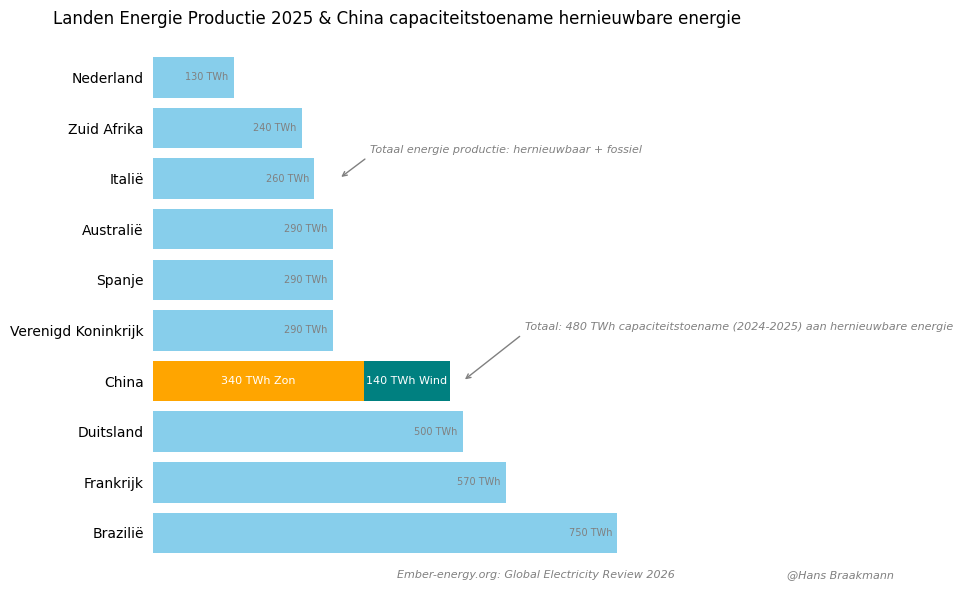

In [6]:
import numpy as np
import matplotlib.pyplot as plt

areas = ["Nederland", "Zuid Afrika", "Italië", "Australië", "Spanje", "Verenigd Koninkrijk", "China", "Duitsland", "Frankrijk", "Brazilië"]
totals = np.array([130, 240, 260, 290, 290, 290, 0, 500, 570, 750])

areas = areas[::-1]
totals = totals[::-1]

fig, ax = plt.subplots(figsize=(10, 6))

bar_country = ax.barh(areas, totals, color="skyblue", label="Total energy production")
bar_solar = ax.barh("China", 340, color="orange")
bar_wind = ax.barh("China", 140, left=340, color="teal")

ax.bar_label(bar_country, labels = [f"{v:.0f} TWh" if v > 0 else "" for v in totals], color="grey", fontsize=7, padding=-35)
ax.bar_label(bar_solar, labels=["340 TWh Zon"], fontsize=8, color="white", label_type="center")
ax.bar_label(bar_wind, labels=["140 TWh Wind"], fontsize=8, color="white", label_type="center")

ax.set_title("Landen Energie Productie 2025 & China capaciteitstoename hernieuwbare energie")
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax.tick_params(axis="both", width=0)
ax.tick_params(axis="x", labelbottom=False)
ax.annotate("Totaal: 480 TWh capaciteitstoename (2024-2025) aan hernieuwbare energie", xy=(500, "China"), xytext=(600, 4),color="grey", fontsize=8, fontstyle="italic", arrowprops=dict(arrowstyle="->", relpos=(0.0,0.0),color="grey",))
ax.annotate("Totaal energie productie: hernieuwbaar + fossiel", xy=(300, "Italië"), xytext=(350,7.5),color="grey", fontsize=8, fontstyle="italic", arrowprops=dict(arrowstyle="->",relpos=(0.0,0.0), color="grey"))
ax.text(0.5, 0, "Ember-energy.org: Global Electricity Review 2026", fontstyle="italic", fontsize=8, color="grey", transform=ax.transAxes)
ax.text(1.3, 0, "@Hans Braakmann", fontstyle="italic", fontsize=8, color="grey", transform=ax.transAxes)
#plt.savefig("Energie.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pad = "/Users/hbraakmann/Downloads/Global-Electricity-Review-2026-–-Report-dataset.csv"
df = pd.read_csv(pad, encoding="latin-1")

clean = ["Solar", "Wind"]
df_china = df.loc[(df["Area"] == "China") & (df["Variable"].isin(clean)) & (df["Unit"] == "TWh")]
df_china = df_china.sort_values("Year")
df_china["yoy_change"] = df_china.groupby(["Area", "Variable"])["Value"].diff().round(-1)
df_china = df_china.dropna(subset="yoy_change")[["Area", "Year", "Variable", "yoy_change", "Unit"]].reset_index(drop=True)
df_china.head()

,Area,Year,Variable,yoy_change,Unit
0,China,2001,Solar,0.0,TWh
1,China,2001,Wind,0.0,TWh
2,China,2002,Solar,0.0,TWh
3,China,2002,Wind,0.0,TWh
4,China,2003,Solar,0.0,TWh


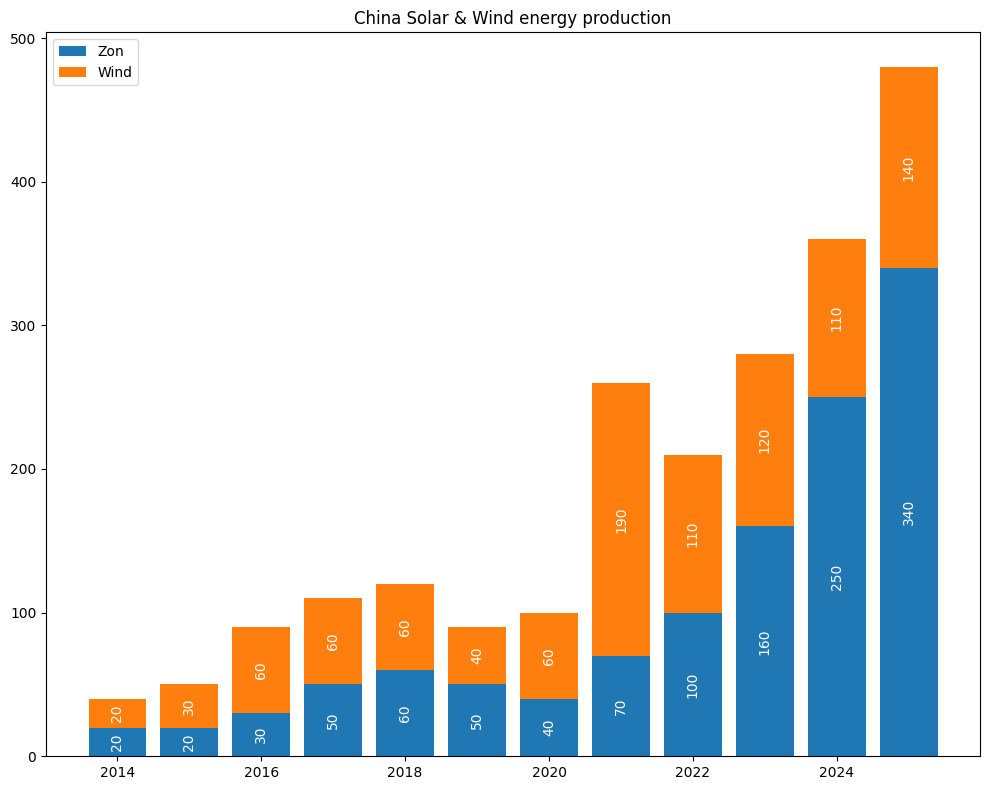

In [5]:
years = np.arange(2014, df_china["Year"].max()+1)
solar = df_china.loc[(df_china["Variable"] == "Solar") & (df_china["Year"] > 2013)]["yoy_change"].values.astype(int)
wind = df_china.loc[(df_china["Variable"] == "Wind") & (df_china["Year"] > 2013)]["yoy_change"].values.astype(int)

fig, ax = plt.subplots(figsize=(10,8))

bars_s = ax.bar(years, solar, label="Zon")
bars_w = ax.bar(years, wind, bottom=solar, label="Wind")

ax.bar_label(bars_s, labels=[f"{s}" if s > 10 else "" for s in solar], color="white", rotation=90, label_type="center")
ax.bar_label(bars_w, labels=[f"{w}" if w > 10 else "" for w in wind], color="white", rotation=90, label_type="center")

ax.set_title("China Solar & Wind energy production")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
df.head()

,Area,Country code,Year,Area type,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
0,Afghanistan,AFG,2000,Country,Electricity demand,Demand,Demand,TWh,0.57,NaN,NaN
1,Afghanistan,AFG,2000,Country,Electricity demand,Demand per capita,Demand per capita,MWh,0.03,NaN,NaN
2,Afghanistan,AFG,2000,Country,Electricity generation,Aggregate fuel,Clean,%,64.58,NaN,NaN
3,Afghanistan,AFG,2000,Country,Electricity generation,Aggregate fuel,Clean,TWh,0.31,NaN,NaN
4,Afghanistan,AFG,2000,Country,Electricity generation,Aggregate fuel,Fossil,%,35.42,NaN,NaN


In [8]:
df["Variable"].unique()

array(['Demand', 'Demand per capita', 'Clean', 'Fossil',
       'Hydro, bioenergy and other renewables', 'Renewables',
       'Wind and solar', 'Bioenergy', 'Coal', 'Gas', 'Hydro', 'Nuclear',
       'Other fossil', 'Other renewables', 'Solar', 'Wind',
       'Total generation', 'Net imports', 'CO2 intensity'], dtype=object)

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_renewables = df.loc[(df["Country code"].notna()) & (df["Year"] == 2025) & (df["Variable"].isin(["Hydro", "Wind", "Solar", "Total generation"])) & (df["Unit"] == "TWh")]
df_renewables = df_renewables[["Area", "Year", "Variable", "Value", "Unit"]]
df_renewables = df_renewables.pivot(index="Area", columns="Variable", values="Value")
df_renewables["Total"] = df_renewables["Hydro"] + df_renewables["Wind"] + df_renewables["Solar"]
df_renewables["pct_total"] = ((df_renewables["Total"] / df_renewables["Total generation"]) * 100).round()
df_renewables = df_renewables.loc[df_renewables["Total generation"] > 100]
df_renewables = df_renewables.sort_values(by=["pct_total"], ascending=True).reset_index()
df_renewables = df_renewables.loc[df_renewables["pct_total"] > 3].nlargest(10, "pct_total").reset_index(drop=True)
df_renewables = df_renewables[["Area", "Hydro", "Solar", "Wind", "Total", "Total generation", "pct_total"]]
df_renewables

Variable,Area,Hydro,Solar,Wind,Total,Total generation,pct_total
0,Norway,144.77,0.53,13.56,158.86,160.81,99.0
1,Brazil,388.63,88.64,117.58,594.85,750.53,79.0
2,Sweden,68.24,4.43,38.90,111.57,170.71,65.0
3,Canada,344.74,10.17,51.48,406.39,652.44,62.0
4,Spain,32.74,62.90,58.76,154.40,287.89,54.0
5,Germany,19.56,89.62,136.03,245.21,500.47,49.0
6,Netherlands,0.05,28.50,33.70,62.25,134.96,46.0
7,Viet Nam,102.35,23.04,14.37,139.76,309.99,45.0
8,Pakistan,39.35,36.61,5.74,81.70,195.03,42.0
9,Italy,41.70,44.63,21.48,107.81,264.70,41.0


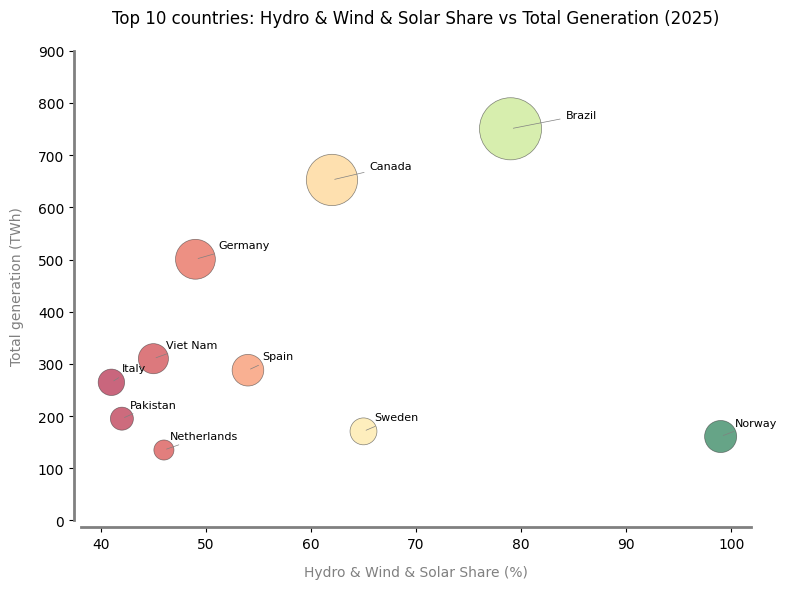

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

# Scale bubble sizes — adjust the divisor to taste
sizes = df_renewables["Total"] / df_renewables["Total"].max() * 2000

cmap = plt.colormaps["RdYlGn"]
norm = plt.Normalize(vmin=df_renewables["pct_total"].min(), vmax=df_renewables["pct_total"].max())
colors = cmap(norm(df_renewables["pct_total"]))

ax.scatter(df_renewables["pct_total"], df_renewables["Total generation"], s=sizes, 
           alpha=0.6, color=colors, edgecolors="#333", linewidth=0.5)

# Label each bubble
for _, row in df_renewables.iterrows():
    ax.annotate(row["Area"], (row["pct_total"], row["Total generation"]),
                xytext=(row["Total"]/15, 10), textcoords="offset points",
                ha="left", va="center", fontsize=8,
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

ax.set_yticks(np.arange(0, 1000, 100))
ax.set_xlabel("Hydro & Wind & Solar Share (%)", labelpad=10, color="grey")
ax.set_ylabel("Total generation (TWh)", labelpad=10, color="grey")
ax.set_title("Top 10 countries: Hydro & Wind & Solar Share vs Total Generation (2025)", pad=20)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_position(("outward", 5))
ax.spines[["left", "bottom"]].set_linewidth(2)
ax.spines[["left", "bottom"]].set_color("grey")
plt.savefig("top_10.png")
plt.tight_layout()
plt.show()

<Axes: xlabel='Year'>

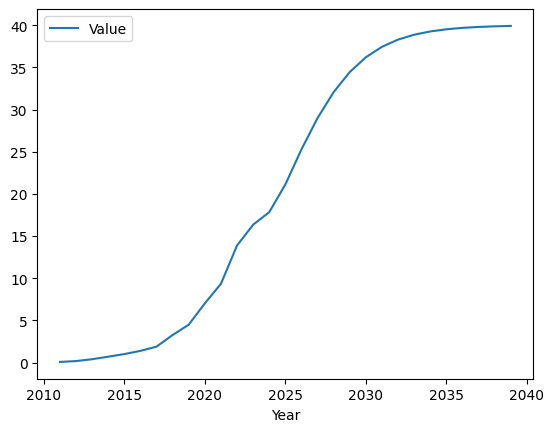

In [34]:
df_nl = df.loc[(df["Country code"] == "NLD") & 
(df["Year"] > 2010) & 
(df["Variable"] == "Solar") & 
(df["Unit"] == "%")][["Year", "Value"]].reset_index(drop=True)

df_nl["diff (100-value)"] = 40 - df_nl["Value"]
df_nl["Q (Diff/Value)"] = df_nl["diff (100-value)"] / df_nl["Value"]
df_nl["factor"] = df_nl["Q (Diff/Value)"].shift(-1) / df_nl["Q (Diff/Value)"]
df_nl.columns = ["Year", "A", "B", "B/A", "factor"]

K = 40
g = df_nl["factor"].mean()
A = df_nl["B/A"].values[0] / g
Nt = 35

jaren = np.arange(2026, 2040)
laatste_waarde = df_nl["A"].values[-1]
t_anker = np.log((K - laatste_waarde) / (laatste_waarde * A)) / np.log(g)

t_vals = t_anker + np.arange(1, len(jaren) + 1)

df_toekomst = pd.DataFrame({
    "Year": jaren,
    "Value": K / (1 + A * g**t_vals)})
df_toekomst

df_huidig = df_nl[["Year", "A"]]
df_huidig.columns = ["Year", "Value"]

df_final = pd.concat([df_huidig, df_toekomst], ignore_index=True)
df_final.plot(x="Year", y="Value")

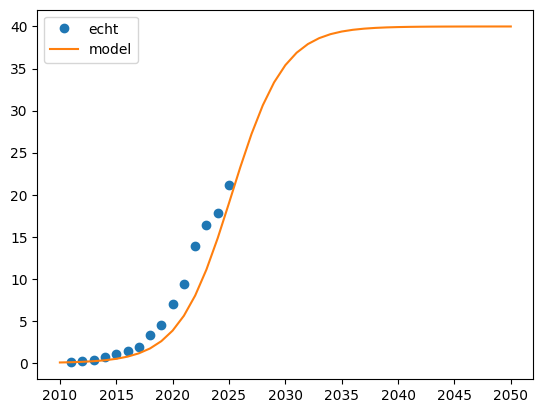

Doel bereikt in 2030, met een waarde van 35.40213798421291 %


In [35]:
K = 40
g = df_nl["factor"].mean()
B = df_nl["B/A"].values[0] / g

# Voorspelling van 2015 tot 2050
jaren = np.arange(2010, 2051)
t = np.arange(len(jaren))
voorspeld = K / (1 + B * g**t)

# Plot
import matplotlib.pyplot as plt
plt.plot(df_nl["Year"], df_nl["A"], "o", label="echt")
plt.plot(jaren, voorspeld, "-", label="model")
plt.legend()
plt.show()

target = 35
idx = np.argmax(voorspeld > target)
print(f"Doel bereikt in {jaren[idx]}, met een waarde van {voorspeld[idx]} %")

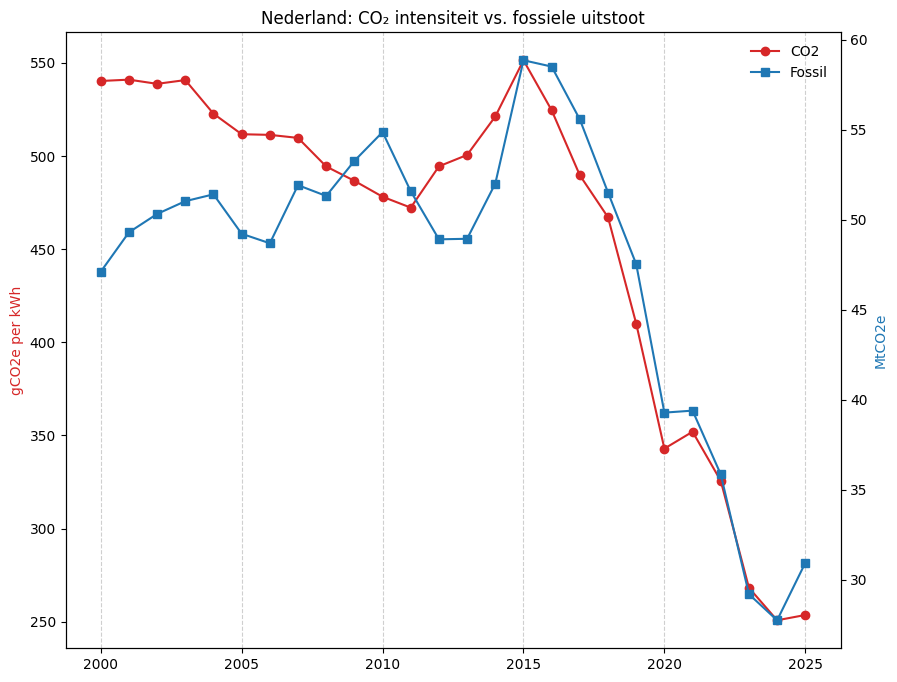

In [116]:

nl_co2 = df.loc[(df["Country code"] == "NLD") & (df["Variable"] == "CO2 intensity")][["Year","Value", "Unit"]].reset_index(drop=True)
nl_fossil = df.loc[(df["Country code"] == "NLD") & (df["Variable"] == "Fossil") & (df["Unit"] == "MtCO2e")][["Year","Value", "Unit"]].reset_index(drop=True)


fig, ax1 = plt.subplots(figsize=(10,8))

ax1.plot(nl_co2["Year"], nl_co2["Value"], marker="o", color="tab:red", label="CO2", zorder=2)
ax1.set_ylabel("gCO2e per kWh", color="tab:red")
ax2 = ax1.twinx()
ax2.plot(nl_fossil["Year"], nl_fossil["Value"], marker="s", color="tab:blue", label="Fossil", zorder=2)
ax2.set_ylabel("MtCO2e", color="tab:blue")

ax1.grid(axis="x", linestyle="--", alpha=0.6, zorder=1)
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88), frameon=False)
plt.title("Nederland: CO₂ intensiteit vs. fossiele uitstoot")
#plt.plot(nl_fossil["Year"], nl_fossil["Value"], marker="o")
plt.show()

In [117]:
nl_co2.columns = ["Year", "Value gCO2e","Unit"]
nl_co2 = nl_co2.drop(columns="Unit")
nl_fossil.columns = ["Year", "Value MtCO2e","Unit"]
nl_fossil = nl_fossil.drop(columns="Unit")

In [121]:
data = pd.merge(nl_co2, nl_fossil, on="Year")
data

,Year,Value gCO2e,Value MtCO2e
0,2000,540.31,47.12
1,2001,541.03,49.31
2,2002,538.78,50.33
3,2003,540.80,51.04
4,2004,522.74,51.42
5,2005,511.72,49.23
6,2006,511.38,48.70
7,2007,509.74,51.93
8,2008,494.40,51.33
9,2009,486.69,53.28
